# K09_02 - Keras Regression mit California Housing

## Lernziele
Nach diesem Notebook koennen Sie:
- ein MLP fuer eine **Regressionsaufgabe** mit Keras aufbauen
- den Unterschied zwischen Klassifikation und Regression in Keras erklaeren
- Output-Schicht, Loss und Metriken fuer Regression passend waehlen
- Regressionsmetriken (MSE, RMSE, MAE, R²) erklaeren und interpretieren
- einen Predicted-vs-Actual-Plot erstellen und lesen
- Lernkurven fuer Regressionsmodelle interpretieren


## Didaktischer Fokus

Leitfrage:
> Wie unterscheidet sich ein Keras-Regressionsmodell
> von einem Keras-Klassifikationsmodell?

Der Keras-Workflow bleibt identisch:
`Daten laden → Skalieren → Modell definieren → Kompilieren → Trainieren → Evaluieren`

Drei Dinge aendern sich:

| | Klassifikation (K09_00) | Regression (dieses Notebook) |
|---|---|---|
| **Output-Schicht** | Dense(n_klassen, softmax) | Dense(1) — kein softmax |
| **Loss** | categorical_crossentropy | mean_squared_error |
| **Metriken** | accuracy | MAE, RMSE, R² |


## Imports und Reproduzierbarkeit


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seeds ganz am Anfang setzen
np.random.seed(42)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow import keras
from tensorflow.keras import layers

print('Alle Bibliotheken geladen.')
print(f'TensorFlow-Version: {tf.__version__}')


Alle Bibliotheken geladen.
TensorFlow-Version: 2.19.0


## 1. California-Housing-Daten laden

**Wichtig fuer die gesamte Metrik-Interpretation:**  
Die Zielvariable `y` ist der **Median-Hauswert in Einheiten von 100.000 USD**.

```
y = 1.5  bedeutet:  150.000 USD
y = 3.0  bedeutet:  300.000 USD
y = 5.0  bedeutet:  500.000 USD  (Maximum im Datensatz)
```

**Achtung:** Im Datensatz sind alle Werte ueber 500.000 USD auf 5.0 gekappt.
Das beeinflusst die Metriken: Das Modell wird an den Raendern (hohe Preise) schwaecher.

| Feature | Bedeutung |
|---|---|
| MedInc | Medianes Einkommen (in 10.000 USD) |
| HouseAge | Medianes Alter der Haeuser |
| AveRooms | Durchschnittliche Zimmeranzahl |
| AveBedrms | Durchschnittliche Schlafzimmer |
| Population | Bevoelkerung des Blocks |
| AveOccup | Durchschnittliche Belegung |
| Latitude | Breitengrad |
| Longitude | Laengengrad |


In [ ]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f'Shape von X: {X.shape}')
print(f'Shape von y: {y.shape}')
print(f'\nZielvariable y (Median-Hauswert in 100.000 USD):')
print(f'  Min:    {y.min():.2f}  ({y.min()*100:.0f}.000 USD)')
print(f'  Max:    {y.max():.2f}  ({y.max()*100:.0f}.000 USD)')
print(f'  Mittel: {y.mean():.2f}  ({y.mean()*100:.0f}.000 USD)')
print()
print('Erste 5 Zeilen:')
display(X.head())


Shape von X: (20640, 8)
Shape von y: (20640,)

Zielvariable y (Median-Hauswert in 100.000 USD):
  Min:    0.15  (15.000 USD)
  Max:    5.00  (500.000 USD)
  Mittel: 2.07  (207.000 USD)

Erste 5 Zeilen:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Verteilung der Zielvariable

Die Zielverteilung zeigt den Deckel bei 5.0 (500.000 USD) –
das ist kein natuerliches Maximum, sondern eine Kappung im Datensatz.
Werte darueber wurden auf 5.0 gesetzt.


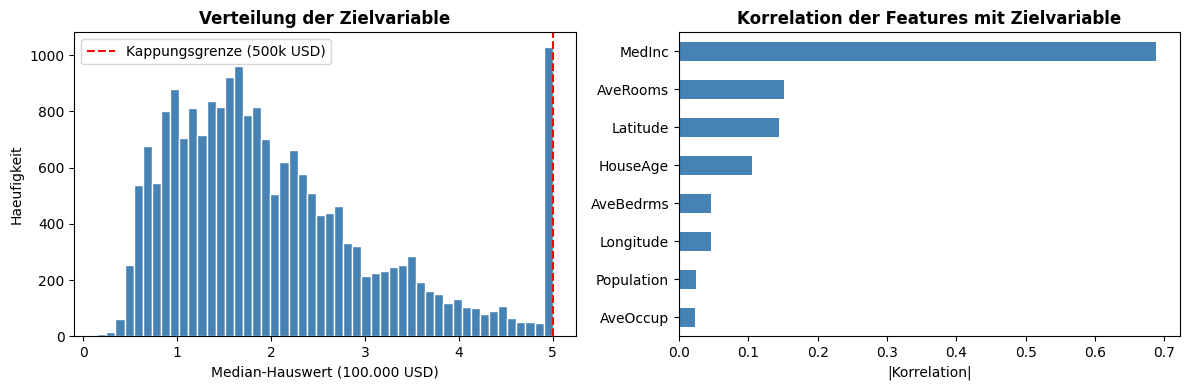

Anteil Werte bei genau 5.0 (gekappt): 27 von 20640 (0.1%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=5.0, color='red', linestyle='--', label='Kappungsgrenze (500k USD)')
axes[0].set_xlabel('Median-Hauswert (100.000 USD)')
axes[0].set_ylabel('Haeufigkeit')
axes[0].set_title('Verteilung der Zielvariable', fontweight='bold')
axes[0].legend()

# Top-10 Features nach Korrelation
corr = X.corrwith(y).abs().sort_values(ascending=True)
corr.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Korrelation der Features mit Zielvariable', fontweight='bold')
axes[1].set_xlabel('|Korrelation|')

plt.tight_layout()
plt.show()

print(f'Anteil Werte bei genau 5.0 (gekappt): {(y == 5.0).sum()} von {len(y)} ({(y==5.0).mean()*100:.1f}%)')


## 2. Trainings- und Testdaten

Bei Regression ist `stratify` nicht anwendbar (keine Klassen).
Der einfache 80/20-Split ist hier Standard.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Trainingsdaten:  {X_train_scaled.shape}')
print(f'Testdaten:       {X_test_scaled.shape}')


Trainingsdaten:  (16512, 8)
Testdaten:       (4128, 8)


## 3. Regressionsmetriken — Erklärung

Bevor wir das Modell bauen, klaeren wir was wir spaeter messen werden.

**MSE – Mean Squared Error**  
Mittlerer quadratischer Fehler. Bestraft grosse Fehler ueberproportional stark.
Schwer direkt zu interpretieren wegen der Quadrierung.
```
MSE = 0.5  ->  schwer direkt lesbar (quadrierte Einheit)
```

**RMSE – Root Mean Squared Error**  
Wurzel aus dem MSE. Vorteil: selbe Einheit wie die Zielvariable.
```
RMSE = 0.70  ->  durchschnittlich 70.000 USD Fehler
```

**MAE – Mean Absolute Error**  
Mittlere absolute Abweichung. Robuster gegenueber Ausreissern als RMSE.
```
MAE = 0.50  ->  durchschnittlich 50.000 USD Fehler
```

**R² – Bestimmtheitsmass**  
Wie viel Prozent der Varianz der Zielvariable erklaert das Modell?
```
R² = 1.00  ->  perfekte Vorhersage
R² = 0.70  ->  Modell erklaert 70% der Varianz
R² = 0.00  ->  Modell nicht besser als der Mittelwert
R² < 0.00  ->  Modell schlechter als der Mittelwert
```

> **Merksatz:** RMSE und MAE sind in Zielgroessen-Einheiten lesbar
> (hier: 100.000 USD). R² ist unabhaengig von der Einheit und
> daher gut fuer Vergleiche zwischen verschiedenen Modellen.


## 4. Regressionsmodell definieren

**Drei wichtige Unterschiede zur Klassifikation:**

```
Klassifikation (K09_00):        Regression (dieses Notebook):

Dense(3, softmax)               Dense(1)
  3 Neuronen                      1 Neuron
  Softmax -> Wahrscheinlichkeit   Keine Aktivierung -> direkte Zahl
  Ausgabe: [0.02, 0.05, 0.93]    Ausgabe: 2.47

Loss: categorical_crossentropy  Loss: mean_squared_error
Metrik: accuracy                Metrik: mean_absolute_error
```


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # 8 Features
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # <- EIN Neuron, KEINE Aktivierung
], name='Regressionsmodell')

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model.summary()


Model: "Regressionsmodell"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

### Parameteranzahl

```
Dense(64):   8 x 64 + 64 Bias  =   576 Parameter
Dense(32):  64 x 32 + 32 Bias  =  2080 Parameter
Dense(1):   32 x  1 +  1 Bias  =    33 Parameter
Gesamt:                            2689 Parameter
```

Zum Vergleich: Das Iris-Modell aus K09_00 hatte nur 131 Parameter.
California Housing hat 8 statt 4 Input-Features und 20.640 statt 150 Samples –
ein realistischerer Datensatz braucht mehr Kapazitaet.


## 5. Modell trainieren

California Housing hat 20.640 Samples – deutlich mehr als Iris.
Das Modell konvergiert typischerweise nach 50-100 Epochen.
Wir trainieren mit 100 Epochen fuer eine saubere Lernkurve.


In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

print('Training abgeschlossen.')
hist_df = pd.DataFrame(history.history)
print(f'Finale Train-MAE: {hist_df["mean_absolute_error"].iloc[-1]:.4f}')
print(f'Finale Val-MAE:   {hist_df["val_mean_absolute_error"].iloc[-1]:.4f}')


Training abgeschlossen.
Finale Train-MAE: 0.3310
Finale Val-MAE:   0.3652


## 6. Lernkurven

Bei Regression zeigen die Lernkurven MSE und MAE statt Accuracy.
Die Interpretation bleibt gleich:
- Kurven sinken -> Modell lernt
- Grosser Abstand Train vs. Val -> Overfitting
- Kurven stagnieren frueh -> Underfitting oder Konvergenz


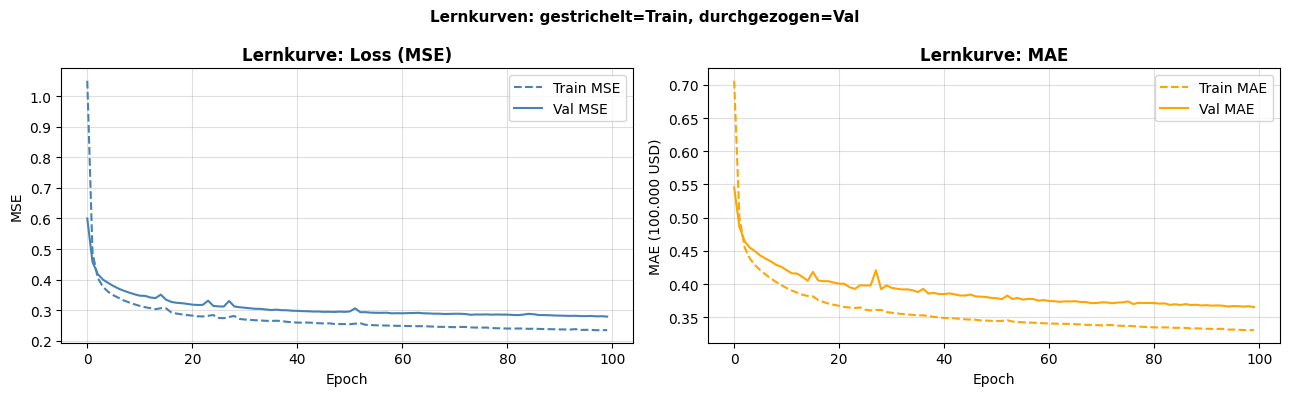

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['loss'],     label='Train MSE', color='steelblue', linestyle='--')
axes[0].plot(hist_df['val_loss'], label='Val MSE',   color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Lernkurve: Loss (MSE)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(hist_df['mean_absolute_error'],     label='Train MAE', color='orange', linestyle='--')
axes[1].plot(hist_df['val_mean_absolute_error'], label='Val MAE',   color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (100.000 USD)')
axes[1].set_title('Lernkurve: MAE', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Lernkurven: gestrichelt=Train, durchgezogen=Val',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Vorhersagen und Regressionsmetriken


In [ ]:
y_pred = model.predict(X_test_scaled, verbose=0).ravel()

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

results = pd.DataFrame({
    'Metrik':       ['MSE', 'RMSE', 'MAE', 'R²'],
    'Wert':         [round(mse,4), round(rmse,4), round(mae,4), round(r2,4)],
    'Interpretation': [
        'Quadratischer Fehler (schwer lesbar)',
        f'Ø {rmse*100:.0f}.000 USD Fehler',
        f'Ø {mae*100:.0f}.000 USD Fehler',
        f'Modell erklaert {r2*100:.1f}% der Varianz'
    ]
})
print(results.to_string(index=False))


Metrik   Wert                       Interpretation
   MSE 0.2821 Quadratischer Fehler (schwer lesbar)
  RMSE 0.5311                  Ø 53.000 USD Fehler
   MAE 0.3635                  Ø 36.000 USD Fehler
    R² 0.7847    Modell erklaert 78.5% der Varianz


## 8. Predicted-vs-Actual-Plot

Das wichtigste visuelle Diagnosewerkzeug fuer Regressionsmodelle.

**Wie lesen?**
- Punkte auf der roten Diagonale: perfekte Vorhersage
- Punkte oberhalb: Modell sagt zu viel vorher (ueberschaetzt)
- Punkte unterhalb: Modell sagt zu wenig vorher (unterschaetzt)
- Systematische Muster (z. B. Faecherfom): Hinweis auf Modellschwaechen


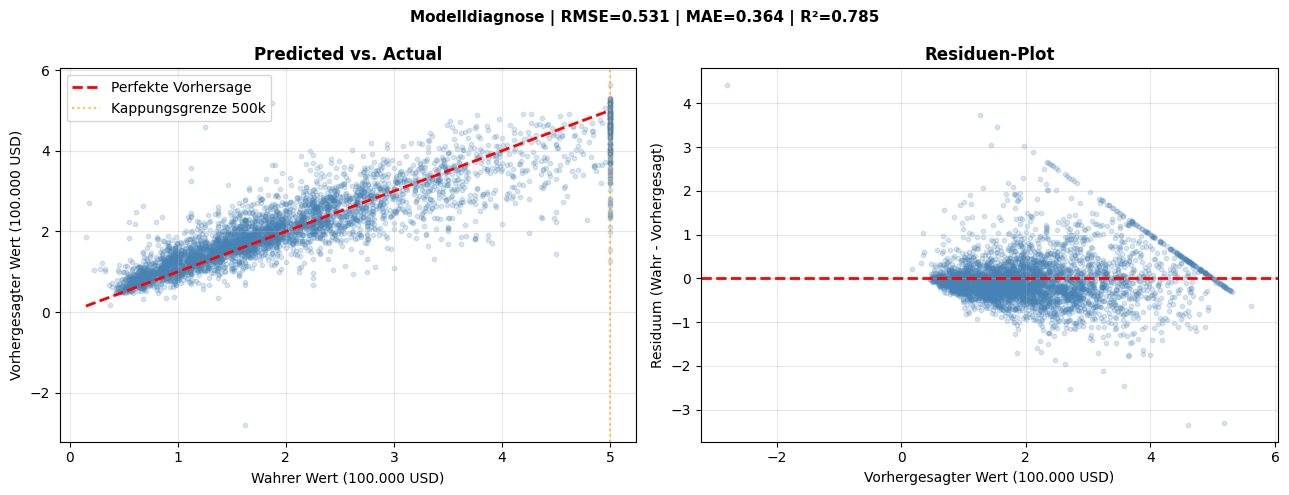

Beobachtungen:
  Punkte an der roten Linie: gute Vorhersage
  Haeufung bei y=5.0: Kappungseffekt sichtbar
  Residuen sollten zufaellig um 0 streuen


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Predicted vs. Actual ---
axes[0].scatter(y_test, y_pred, alpha=0.2, s=10, color='steelblue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Perfekte Vorhersage')
axes[0].set_xlabel('Wahrer Wert (100.000 USD)')
axes[0].set_ylabel('Vorhergesagter Wert (100.000 USD)')
axes[0].set_title('Predicted vs. Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kappungsgrenze einzeichnen
axes[0].axvline(x=5.0, color='orange', linestyle=':', alpha=0.7,
                label='Kappungsgrenze 500k')
axes[0].legend()

# --- Residuen-Plot ---
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=10, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Vorhergesagter Wert (100.000 USD)')
axes[1].set_ylabel('Residuum (Wahr - Vorhergesagt)')
axes[1].set_title('Residuen-Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Modelldiagnose | RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Beobachtungen:')
print(f'  Punkte an der roten Linie: gute Vorhersage')
print(f'  Haeufung bei y=5.0: Kappungseffekt sichtbar')
print(f'  Residuen sollten zufaellig um 0 streuen')


## 9. Vergleich: Klassifikation vs. Regression in Keras

| Aspekt | Klassifikation (K09_00) | Regression (dieses Notebook) |
|---|---|---|
| **Zielvariable** | Klasse (diskret) | Zahl (kontinuierlich) |
| **Output-Neuronen** | n_klassen (z. B. 3) | 1 |
| **Output-Aktivierung** | softmax | keine (linear) |
| **Loss** | categorical_crossentropy | mean_squared_error |
| **Hauptmetrik** | accuracy | RMSE / MAE / R² |
| **Diagnoseplot** | Konfusionsmatrix | Predicted vs. Actual |
| **One-Hot-Encoding** | ja | nein |
| **Interpretation** | Klasse mit max. Prob. | direkte Zahl |

**Was bleibt gleich:**
- `Sequential`-Modell
- `Dense`-Layer mit `relu` in Hidden Layers
- `StandardScaler` fuer Eingaben
- `model.fit()` mit `validation_split`
- Lernkurven-Diagnose
- `adam`-Optimierer


## 10. Laengere Uebungsaufgabe

**Aufgabe 1 – Unterschiede erklaeren**
Erklaeren Sie den Unterschied zwischen dem Iris-Klassifikationsmodell (K09_00)
und diesem Regressionsmodell in Bezug auf:
- Output-Schicht und Aktivierung
- Loss-Funktion
- Metriken und Diagnoseplot

**Aufgabe 2 – Modell variieren**
Testen Sie mindestens zwei Varianten und vergleichen Sie RMSE und R²:
- Fuegen Sie einen dritten Hidden Layer hinzu
- Erhoehen Sie die Neuronenzahl auf Dense(128)+Dense(64)
- Reduzieren Sie auf Dense(16)

**Aufgabe 3 – Metriken interpretieren**
Interpretieren Sie Ihre Ergebnisse konkret:
- Was bedeutet Ihr RMSE-Wert in Dollar?
- Was sagt R² ueber die Erklaerungskraft des Modells?
- Welche Metrik wuerden Sie einem Auftraggeber berichten und warum?

**Aufgabe 4 – Predicted-vs-Actual analysieren**
Betrachten Sie den Predicted-vs-Actual-Plot:
- Wo weicht das Modell am staerksten ab?
- Was passiert bei Werten nahe der Kappungsgrenze (5.0)?
- Ist das Residuenmuster zufaellig oder systematisch?

**Aufgabe 5 – Reflexion**
- Warum braucht Regression eine andere Output-Schicht als Klassifikation?
- Warum ist Accuracy hier keine sinnvolle Metrik?
- Wann wuerden Sie RMSE bevorzugen, wann MAE?


In [ ]:
# Aufgabe 2 - Modell variieren
# Veraendern Sie die Architektur und vergleichen Sie die Metriken.

model_variante = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),   # <- hier variieren
    layers.Dense(64,  activation='relu'),   # <- hier variieren
    layers.Dense(1)
], name='Variante')

model_variante.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_v = model_variante.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

y_pred_v = model_variante.predict(X_test_scaled, verbose=0).ravel()
rmse_v = np.sqrt(mean_squared_error(y_test, y_pred_v))
mae_v  = mean_absolute_error(y_test, y_pred_v)
r2_v   = r2_score(y_test, y_pred_v)

vergleich = pd.DataFrame({
    'Modell': ['Basismodell (64+32)', 'Variante'],
    'Parameter': [model.count_params(), model_variante.count_params()],
    'RMSE': [round(rmse,4), round(rmse_v,4)],
    'MAE':  [round(mae,4),  round(mae_v,4)],
    'R²':   [round(r2,4),   round(r2_v,4)]
})
print(vergleich.to_string(index=False))


             Modell  Parameter   RMSE    MAE     R²
Basismodell (64+32)       2689 0.5311 0.3635 0.7847
           Variante       9473 0.5275 0.3609 0.7877


## 11. Fazit

- Der Keras-Workflow bleibt bei Regression identisch zur Klassifikation.
- **Drei Dinge aendern sich:** Output-Schicht, Loss und Metriken.
- Die Output-Schicht `Dense(1)` ohne Aktivierung gibt direkt einen numerischen Wert aus.
- **RMSE** und **MAE** sind in Zieleinheiten interpretierbar (hier: 100.000 USD).
- **R²** ist einheitenunabhaengig und gut fuer Modellvergleiche.
- Der **Predicted-vs-Actual-Plot** ist das zentrale Diagnosewerkzeug fuer Regression.
- California Housing zeigt einen typischen Praxisfall: Kappungseffekte
  und nichtlineare Zusammenhaenge machen perfekte Vorhersagen unmoeglich.
